In [ ]:
# Lecture 5
# import packages
from scipy.stats import chi2
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Log
from statsmodels.genmod.families.links import Identity
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
os.chdir(r'C:\Users\Linda\Desktop\ST5213py')
pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *

# fig_save_dir = r"C:/Users/Linda/OneDrive - National University of Singapore/ST5213 2627/Lectures/Lecture_5/figure"

In [2]:
# read and preprocess skin dataset
df = pd.read_csv('datasets/skin.txt', sep='\t')
print(df,'\n')

# Assign Town and Age as categorical variables
cols_to_cat = ['Town', 'Age']
df[cols_to_cat] = df[cols_to_cat].astype('category')

print(df.info())

    Cases  Town    Age  Population
0       1     0  15-24      172675
1      16     0  25-34      123065
2      30     0  35-44       96216
3      71     0  45-54       92051
4     102     0  55-64       72159
5     130     0  65-74       54722
6     133     0  75-84       32185
7      40     0    85+        8328
8       4     1  15-24      181343
9      38     1  25-34      146207
10    119     1  35-44      121374
11    221     1  45-54      111353
12    259     1  55-64       83004
13    310     1  65-74       55932
14     65     1    85+        7583 

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Cases       15 non-null     int64   
 1   Town        15 non-null     category
 2   Age         15 non-null     category
 3   Population  15 non-null     int64   
dtypes: category(2), int64(2)
memory usage: 482.0 bytes
None


In [3]:
#  summary of quantitative variables 
print(df.describe(), '\n')

# count in each category for categorical variable
for j in df.select_dtypes('category'):
    print(df[j].value_counts(),'\n')

# Create the contingency tables
tab_popn = df.pivot(index="Town", columns='Age', values="Population")
print(tab_popn.to_string(float_format="%.0f"), '\n')

tab_cases = df.pivot(index="Town", columns='Age', values="Cases")
print(tab_cases.to_string(float_format="%.0f"), '\n')

           Cases     Population
count   15.00000      15.000000
mean   102.60000   90546.466667
std     95.15311   53777.137738
min      1.00000    7583.000000
25%     34.00000   55327.000000
50%     71.00000   92051.000000
75%    131.50000  122219.500000
max    310.00000  181343.000000 

Town
0    8
1    7
Name: count, dtype: int64 

Age
15-24    2
25-34    2
35-44    2
45-54    2
55-64    2
65-74    2
85+      2
75-84    1
Name: count, dtype: int64 

Age   15-24  25-34  35-44  45-54  55-64  65-74  75-84  85+
Town                                                      
0    172675 123065  96216  92051  72159  54722  32185 8328
1    181343 146207 121374 111353  83004  55932    NaN 7583 

Age   15-24  25-34  35-44  45-54  55-64  65-74  75-84  85+
Town                                                      
0         1     16     30     71    102    130    133   40
1         4     38    119    221    259    310    NaN   65 



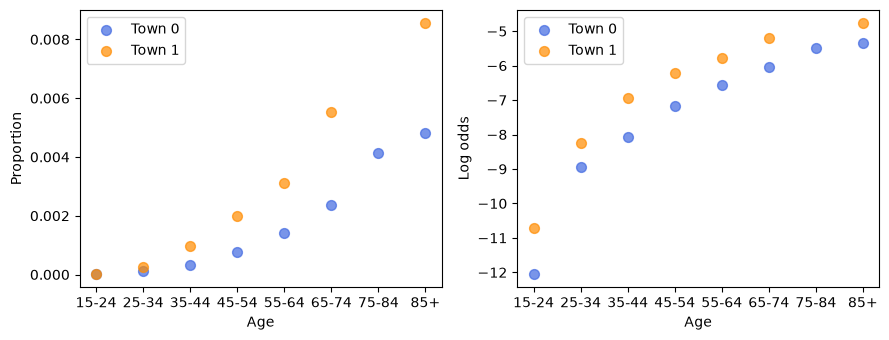

In [4]:
# Visualize data 
df['prop'] = df['Cases'] / df['Population']
colors = {0: "royalblue", 1: "darkorange"}
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 3.5))

for town in [0, 1]:
    town_df = df[df["Town"] == town]  # df that contains only obs with Town equal to a particular value
    axes[0].scatter(town_df['Age'], town_df["prop"], color=colors[town], s=50, alpha=0.7, label=f"Town {town}")
    axes[1].scatter(town_df['Age'], logit(town_df["prop"]), color=colors[town], s=50, alpha=0.7, label=f"Town {town}")

axes[0].set_xlabel('Age')
axes[0].set_ylabel("Proportion")
axes[0].legend()

axes[1].set_xlabel('Age')
axes[1].set_ylabel("Log odds")
axes[1].legend()

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "prop_log_odds.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [5]:
# Fit GLM 

# Create a variable to represent failures
df['fail'] = df['Population'] - df['Cases']

fm = glm('Cases + fail ~ Age + Town', df, family=Binomial()).fit()
print(fm.summary2(),'\n')

               Results: Generalized linear model
Model:                GLM               AIC:            110.1024
Link Function:        Logit             BIC:            -11.0974
Dependent Variable:   ['Cases', 'fail'] Log-Likelihood: -46.051 
Date:                 2026-07-10 11:54  LL-Null:        -1208.7 
No. Observations:     15                Deviance:       5.1509  
Df Model:             8                 Pearson chi2:   5.09    
Df Residuals:         6                 Scale:          1.0000  
Method:               IRLS                                      
----------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
----------------------------------------------------------------
Intercept    -11.6936   0.4492 -26.0304 0.0000 -12.5741 -10.8132
Age[T.25-34]   2.6291   0.4675   5.6242 0.0000   1.7129   3.5454
Age[T.35-44]   3.8463   0.4547   8.4595 0.0000   2.9551   4.7374
Age[T.45-54]   4.5954   0.4510  10.1884 0

In [6]:
print(fm.df_resid, '\n')
print(fm.params)

6 

Intercept      -11.693637
Age[T.25-34]     2.629145
Age[T.35-44]     3.846272
Age[T.45-54]     4.595381
Age[T.55-64]     5.089013
Age[T.65-74]     5.650310
Age[T.75-84]     6.208871
Age[T.85+]       6.183461
Town[T.1]        0.854916
dtype: float64


In [7]:
# Goodness of fit test for fm
print(chi2.sf(fm.deviance, fm.df_resid))

# Goodness of fit test for null model
df_null = fm.nobs - 1
print(df_null,)
print(chi2.sf(fm.null_deviance, df_null))

0.5246072783600031
14
0.0


In [8]:
# Analysis of deviance of fm
print(anova_single(fm), '\n')

fma = glm('Cases + fail ~ Town + Age', data=df, family=Binomial()).fit()
print(anova_single(fma), '\n')

      Resid. Df   Resid. Dev   Df     Deviance      Pr(>Chi)
NULL       14.0  2330.463688  NaN          NaN           NaN
Age         7.0   232.275668  7.0  2098.188020  0.000000e+00
Town        6.0     5.150922  1.0   227.124746  2.525831e-51 

      Resid. Df   Resid. Dev   Df     Deviance      Pr(>Chi)
NULL       14.0  2330.463688  NaN          NaN           NaN
Town       13.0  2207.256890  1.0   123.206799  1.256465e-28
Age         6.0     5.150922  7.0  2202.105968  0.000000e+00 



In [9]:
# Fit GLM with interaction term (saturated model)
fm1 = update_glm(fm, add='Age:Town')
print(fm1.summary2(), '\n')

                    Results: Generalized linear model
Model:                  GLM                  AIC:               116.9514  
Link Function:          Logit                BIC:               0.0000    
Dependent Variable:     ['Cases', 'fail']    Log-Likelihood:    -43.476   
Date:                   2026-07-10 11:54     LL-Null:           -1208.7   
No. Observations:       15                   Deviance:          1.4503e-11
Df Model:               14                   Pearson chi2:      1.40e-25  
Df Residuals:           0                    Scale:             1.0000    
Method:                 IRLS                                              
--------------------------------------------------------------------------
                        Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
--------------------------------------------------------------------------
Intercept              -12.0592   1.0000 -12.0591 0.0000 -14.0191 -10.0992
Age[T.25-34]             3.1114   1.0308   3.0

c:\Users\Linda\Desktop\ST5213py\ST5213venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Linda\Desktop\ST5213py\ST5213venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Linda\Desktop\ST5213py\ST5213venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


In [10]:
# compare fitted and observed proportions
result = np.column_stack((df['prop'], fm1.fittedvalues, fm.fittedvalues)) * 1000
with np.printoptions(precision=3, suppress=True):
    print(result)

[[0.006 0.006 0.008]
 [0.13  0.13  0.116]
 [0.312 0.312 0.391]
 [0.771 0.771 0.826]
 [1.414 1.414 1.352]
 [2.376 2.376 2.368]
 [4.132 4.132 4.132]
 [4.803 4.803 4.029]
 [0.022 0.022 0.02 ]
 [0.26  0.26  0.272]
 [0.98  0.98  0.918]
 [1.985 1.985 1.94 ]
 [3.12  3.12  3.174]
 [5.542 5.542 5.55 ]
 [8.572 8.572 9.422]]


In [11]:
# compare model with main terms only and full model
print(anova_nested(fm, fm1))

         Resid. Df    Resid. Dev   Df  Deviance  Pr(>Chi)
Model 1        6.0  5.150922e+00  NaN       NaN       NaN
Model 2        0.0  1.450329e-11  6.0  5.150922  0.524607


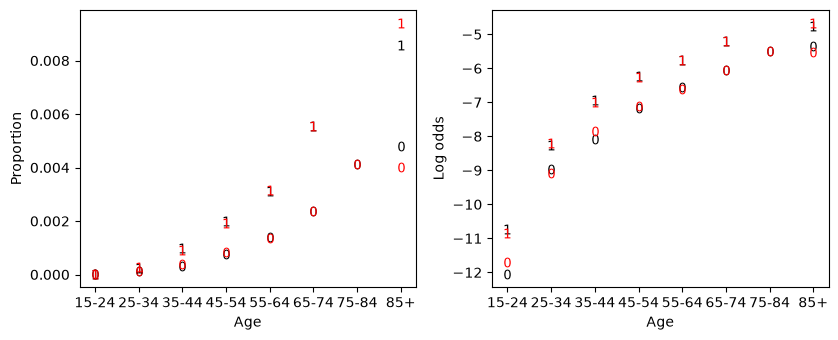

In [12]:
df['fitted_logit'] = fm.fittedvalues
df['nAge'] = df['Age'].cat.codes + 1
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8.5, 3.5))
town_markers = {0: r"$0$", 1: r"$1$"}

for town_val, group in df.groupby("Town"):
    axes[0].scatter(group['nAge'], group['prop'],
        marker=town_markers[town_val], color="black", linewidths=0, s=50)
    
    axes[0].scatter(group['nAge'], group['fitted_logit'],
        marker=town_markers[town_val], color="red", linewidths=0, s=50)

    axes[1].scatter(group['nAge'], logit(group['prop']),
        marker=town_markers[town_val], color="black", linewidths=0, s=50)
    
    axes[1].scatter(group['nAge'], logit(group['fitted_logit']),
        marker=town_markers[town_val], color="red", linewidths=0, s=50)

tick_positions = range(1, len(df['Age'].cat.categories) + 1) 
tick_labels = df['Age'].cat.categories

# Apply the labels to both axes
for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)  

axes[0].set_xlabel('Age')
axes[0].set_ylabel("Proportion")

axes[1].set_xlabel('Age')
axes[1].set_ylabel("Log odds")

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "fitted.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [13]:
# Alternative log link
fm2 = glm('Cases + fail ~ Age + Town', df, family=Binomial(link=Log())).fit()
print(fm2.summary2())

               Results: Generalized linear model
Model:                GLM               AIC:            110.1733
Link Function:        Log               BIC:            -11.0265
Dependent Variable:   ['Cases', 'fail'] Log-Likelihood: -46.087 
Date:                 2026-07-10 11:54  LL-Null:        -1208.7 
No. Observations:     15                Deviance:       5.2218  
Df Model:             8                 Pearson chi2:   5.16    
Df Residuals:         6                 Scale:          1.0000  
Method:               IRLS                                      
----------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
----------------------------------------------------------------
Intercept    -11.6920   0.4492 -26.0278 0.0000 -12.5724 -10.8115
Age[T.25-34]   2.6290   0.4675   5.6241 0.0000   1.7128   3.5452
Age[T.35-44]   3.8456   0.4546   8.4584 0.0000   2.9545   4.7367
Age[T.45-54]   4.5938   0.4510  10.1855 0

c:\Users\Linda\Desktop\ST5213py\ST5213venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The Log link function does not respect the domain of the Binomial family.
  warnings.warn((f"The {type(family.link).__name__} link function "


In [14]:
# Alternative identity link
fm3 = glm('Cases + fail ~ Age + Town', df, family=Binomial(link=Identity())).fit(maxiter=200, tol=1e-10)
print(fm3.summary2())

              Results: Generalized linear model
Model:              GLM               AIC:            318.6967
Link Function:      Identity          BIC:            197.4970
Dependent Variable: ['Cases', 'fail'] Log-Likelihood: -150.35 
Date:               2026-07-10 11:54  LL-Null:        -1208.7 
No. Observations:   15                Deviance:       213.75  
Df Model:           8                 Pearson chi2:   200.    
Df Residuals:       6                 Scale:          1.0000  
Method:             IRLS                                      
--------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
--------------------------------------------------------------
Intercept        0.0000   0.0000  0.7399 0.4594 -0.0000 0.0000
Age[T.25-34]     0.0001   0.0000  4.9360 0.0000  0.0001 0.0002
Age[T.35-44]     0.0006   0.0001 10.6741 0.0000  0.0005 0.0007
Age[T.45-54]     0.0014   0.0001 16.0899 0.0000  0.0012 0.0015
Age[T.5

c:\Users\Linda\Desktop\ST5213py\ST5213venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Binomial family.
  warnings.warn((f"The {type(family.link).__name__} link function "


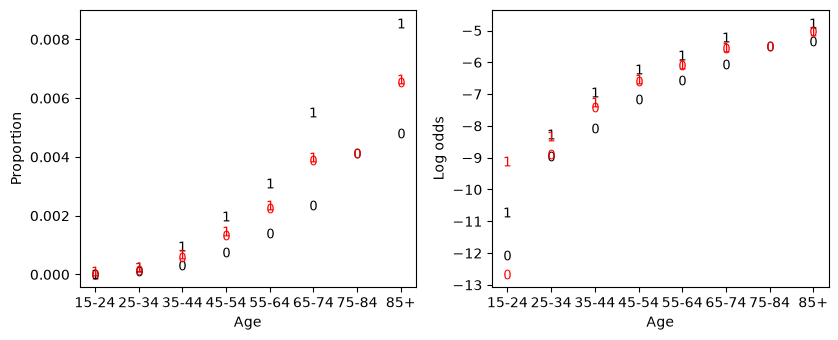

In [15]:
df['fitted_identity'] = fm3.fittedvalues
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8.5, 3.5))
town_markers = {0: r"$0$", 1: r"$1$"}

for town_val, group in df.groupby("Town"):
    axes[0].scatter(group['nAge'], group['prop'],
        marker=town_markers[town_val], color="black", linewidths=0, s=50)
    
    axes[0].scatter(group['nAge'], group['fitted_identity'],
        marker=town_markers[town_val], color="red", linewidths=0, s=50)

    axes[1].scatter(group['nAge'], logit(group['prop']),
        marker=town_markers[town_val], color="black", linewidths=0, s=50)
    
    axes[1].scatter(group['nAge'], logit(group['fitted_identity']),
        marker=town_markers[town_val], color="red", linewidths=0, s=50)

tick_positions = range(1, len(df['Age'].cat.categories) + 1) 
tick_labels = df['Age'].cat.categories

# Apply the labels to both axes
for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)  

axes[0].set_xlabel('Age')
axes[0].set_ylabel("Proportion")

axes[1].set_xlabel('Age')
axes[1].set_ylabel("Log odds")

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "fitted_fm3.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [16]:
# Residuals for fm (treating the response as y_i/m_i where y_i ~ B(m_i, pi_i))
res_response = fm.resid_response / df['Population']
print(res_response.head(), '\n')

res_deviance = fm.resid_deviance
print(res_deviance.head(), '\n')

res_pearson = fm.resid_pearson 
print(res_pearson.head(), '\n')

res_working = fm.resid_working / (df['Population'] ** 2)
print(res_working.head(), '\n')

0   -0.000003
1    0.000014
2   -0.000079
3   -0.000055
4    0.000061
dtype: float64 

0   -0.389216
1    0.458031
2   -1.282964
3   -0.582677
4    0.444656
dtype: float64 

0   -0.367561
1    0.467205
2   -1.237414
3   -0.576158
4    0.447973
dtype: float64 

0   -0.306168
1    0.123828
2   -0.201881
3   -0.066108
4    0.045381
dtype: float64 



In [17]:
# Standardized deviance residuals for fm
res_deviance_std = res_deviance / np.sqrt(1-hat_diag(fm))
print(res_deviance_std.head(), '\n')

# Standardized Pearson residuals for fm
res_pearson_std = res_pearson / np.sqrt(1-hat_diag(fm))
print(res_pearson_std.head())

0   -0.462193
1    0.544036
2   -1.564096
3   -0.757647
4    0.602514
dtype: float64 

0   -0.436478
1    0.554933
2   -1.508565
3   -0.749170
4    0.607008
dtype: float64


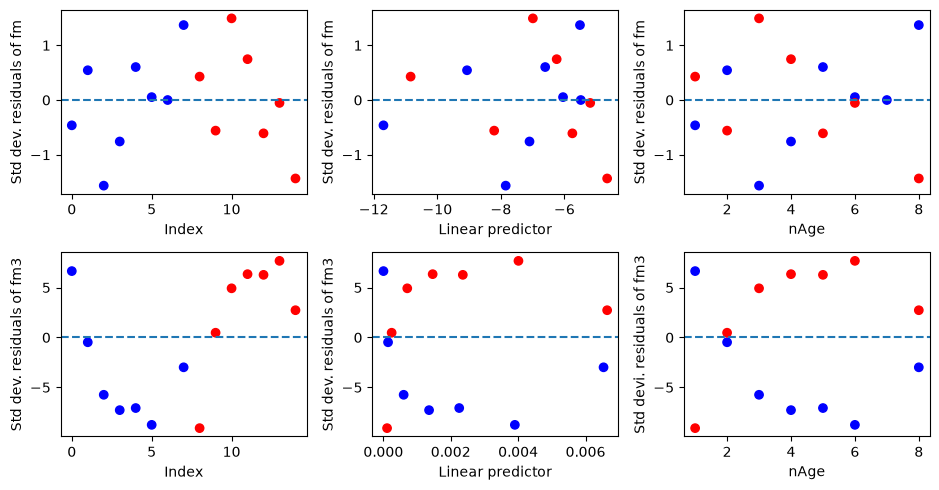

In [18]:
# Standardized deviance residuals for fm3
res_deviance_std_fm3 = fm3.resid_deviance / np.sqrt(1-hat_diag(fm3))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9.5, 5))
cols = np.array(['blue', 'red'])

axes[0,0].scatter(range(len(df)), res_deviance_std, color=cols[df['Town']])
axes[0,0].axhline(0, linestyle='--')
axes[0,0].set_xlabel("Index")
axes[0,0].set_ylabel("Std dev. residuals of fm")

axes[0,1].scatter(fm.predict(df, which='linear'), res_deviance_std, color=cols[df['Town']])
axes[0,1].axhline(0, linestyle='--')
axes[0,1].set_xlabel("Linear predictor")
axes[0,1].set_ylabel("Std dev. residuals of fm")
    
axes[0,2].scatter(df['nAge'], res_deviance_std, color=cols[df['Town']])
axes[0,2].axhline(0, linestyle='--')
axes[0,2].set_xlabel("nAge")
axes[0,2].set_ylabel("Std dev. residuals of fm")

axes[1,0].scatter(range(len(df)), res_deviance_std_fm3, color=cols[df['Town']])
axes[1,0].axhline(0, linestyle='--')
axes[1,0].set_xlabel("Index")
axes[1,0].set_ylabel("Std dev. residuals of fm3")

axes[1,1].scatter(fm3.predict(df, which='linear'), res_deviance_std_fm3, color=cols[df['Town']])
axes[1,1].axhline(0, linestyle='--')
axes[1,1].set_xlabel("Linear predictor")
axes[1,1].set_ylabel("Std dev. residuals of fm3")
    
axes[1,2].scatter(df['nAge'], res_deviance_std_fm3, color=cols[df['Town']])
axes[1,2].axhline(0, linestyle='--')
axes[1,2].set_xlabel("nAge")
axes[1,2].set_ylabel("Std devi. residuals of fm3")

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "residuals.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [19]:
fm3.resid_deviance / np.sqrt(1-hat_diag(fm3))

0     6.649618
1    -0.481879
2    -5.747556
3    -7.285247
4    -7.075470
5    -8.760773
6          NaN
7    -2.993123
8    -9.089456
9     0.472105
10    4.923552
11    6.342475
12    6.273953
13    7.674647
14    2.728873
dtype: float64

                 Generalized Linear Model Regression Results                  
Dep. Variable:      ['Cases', 'fail']   No. Observations:                   15
Model:                            GLM   Df Residuals:                       12
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -135.29
Date:                Fri, 10 Jul 2026   Deviance:                       183.63
Time:                        11:54:02   Pearson chi2:                     141.
No. Iterations:                    11   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.8274      0.091   -108.553      0.0

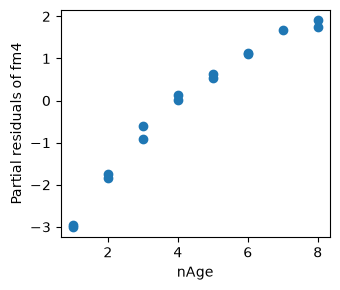

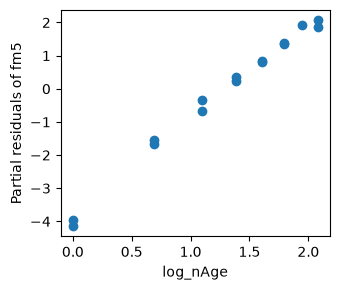

In [20]:
# Fit GLM with numeric Age variable
fm4 = glm('Cases + fail ~ nAge + Town', df, family=Binomial()).fit()
print(fm4.summary(), '\n')

# Partial residuals
res_working = fm4.resid_working / (df['Population'] ** 2) 
res_partial = res_working + (df['nAge'] - np.mean(df['nAge'])) * fm4.params['nAge']
print(res_partial, '\n')

plt.figure(figsize=(3.5, 3))
plt.scatter(df['nAge'], res_partial)
plt.xlabel('nAge')
plt.ylabel('Partial residuals of fm4')
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "partialfm4.pdf")
# plt.savefig(fig_path, bbox_inches="tight") 

# Fit GLM with numeric Age variable
df['log_nAge'] = np.log(df['nAge'])
fm5 = glm('Cases + fail ~ log_nAge + Town', df, family=Binomial()).fit()
print(fm5.summary(), '\n')

# Partial residuals
res_working = fm5.resid_working / (df['Population'] ** 2) 
res_partial = res_working + (df['log_nAge'] - np.mean(df['log_nAge'])) * fm5.params['log_nAge']
print(res_partial, '\n')

plt.figure(figsize=(3.5, 3))
plt.scatter(df['log_nAge'], res_partial)
plt.xlabel('log_nAge')
plt.ylabel('Partial residuals of fm5')
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "partialfm5.pdf")
# plt.savefig(fig_path, bbox_inches="tight") 